In [1]:
import os
import sys
# set working directory
#print(f"{__file__ = }")
print(f"{sys.path = }")
print("working dir:", os.getcwd())
os.chdir("../riemannian_la")
print("working dir:", os.getcwd())
from models import LinearModel, Model_from_func
from getdata import gen_log_regression_data
from train import train
from laplace_approx import Laplace, vector_to_parameterdict
from utils import loss_func_from_target_sigma, make_functional_fwd_xs, functional_loss, functional_loss_for_vmap, sum_loss, neglog_loss
from discrete_sampler import discrete_function_sampler, discrete_model_sampler
from riemann_sampler import Riemann_sampler, riemann_plotter
from integration import integrator
from torch.func import grad, jvp, vjp, hessian, jacfwd, jacrev, vmap, functional_call
from matplotlib import pyplot as plt
from laplace_approx import Laplace
from MCMC_sampler import MCMC_sampler
import torch
from models import functional_banana
from MCMC_sampler import MCMC_sampler
import seaborn as sns
import pandas as pd
from BQ_rays_subspace import BayesianQuadrature_rays
import hamiltorch

fig_folder = "../report/figures"
os.makedirs(fig_folder, exist_ok=True)
torch.manual_seed(0)
"""
A series of usage tests for the integrator function
Banana model:
1)  discrete integration over function:
    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.
    Here, the paramters folow the posterior distribution given (exactly) by the banana FUNCTION

2)  discrete integration over model:
    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.
    Here, the paramters folow the posterior distribution given (exactly) by the banana MODEL

3)  laplace integration over model:
    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.
    Here, the paramters folow the laplace approximation of the posterior distribution given by the banana MODEL

4)  MCMC-integration over banana model posterior

5)  Riemannian Laplace approximation

6)  Bayesian Quadrature - Riemannian Laplace approximation


"""


sys.path = ['/Users/simondanieleiriksson/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/simondanieleiriksson/.pyenv/versions/3.12.7/lib/python3.12', '/Users/simondanieleiriksson/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages', '/Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la']
working dir: /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la
working dir: /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la


'\nA series of usage tests for the integrator function\nBanana model:\n1)  discrete integration over function:\n    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.\n    Here, the paramters folow the posterior distribution given (exactly) by the banana FUNCTION\n\n2)  discrete integration over model:\n    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.\n    Here, the paramters folow the posterior distribution given (exactly) by the banana MODEL\n\n3)  laplace integration over model:\n    We want to take the expectation of the output of tiny_ridiculess_model_class (which is equal to x^2 + y^2) over the parameterspace, restricted to some box.\n    Here, the paramters folow the laplace approximation of the posterior distribution given by the banana MODEL\n\n4)  MCMC-integration

In [2]:

n_mesh = 100
curvature = 0.25
span = 10
plot_xlim=(-4,4)
plot_ylim=(-1,4)


banana_function = functional_banana(curvature=curvature, sigma_x=2.0, sigma_y=.5)
xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function(xs[0]).unsqueeze(0)
class tiny_ridiculess_model_class(torch.nn.Module):
    def __init__(self, n_params):
        super().__init__()
        self.params = torch.nn.Parameter(torch.arange(n_params).float())
    def forward(self, x):
        #return torch.sin(self.params*3.1).sum().repeat(x.shape[0], 1)**2
        #return torch.ones(x.shape[0], 1)
        #return self.params.sum().repeat(x.shape[0], 1)**2
        return self.params.sum().repeat(x.shape[0], 1)
        
evaluation_model = tiny_ridiculess_model_class(n_params=2)
functional_evaluation_model = make_functional_fwd_xs(evaluation_model)  # make functional version of model
banana_model = Model_from_func(banana_function, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
print(f"{banana_model(x) = }")

xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function(xs[0]).unsqueeze(0)

limits = [[-span, span], [-span, span]]
const_prior = lambda x: torch.tensor(0.0)



banana_function(x) = tensor([0.1592])
banana_model(x) = tensor([0.1592], grad_fn=<UnsqueezeBackward0>)


 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/torch/functional.py:534: UserWarning:torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3596.)


1) When using discrete integration over banana FUNCTION we get integral_discrete = tensor([[0.9807]])


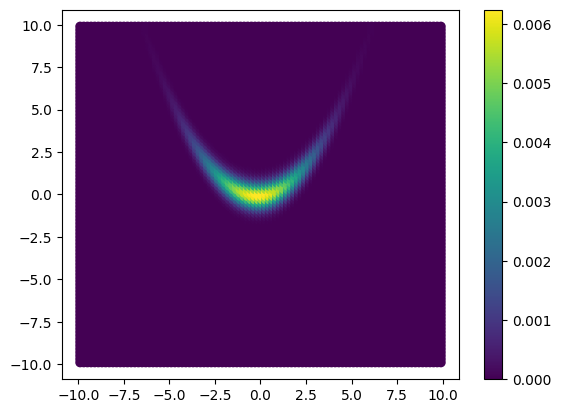

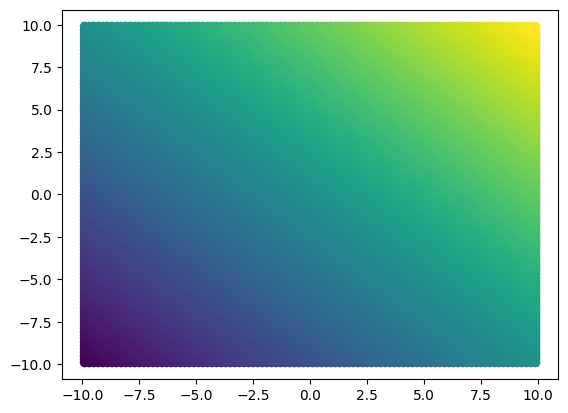

In [3]:
####################################
# 1) discrete integration over function
####################################
#Let's do discrete integration with the banana function
#banana_function = functional_banana(curvature=2.0, sigma_x=2.0, sigma_y=1.0)
#neg_banana = lambda x: -functional_banana(curvature=0.0, sigma_x=1.0, sigma_y=1.0)(x)
discrete_sampler_fn = discrete_function_sampler(func=banana_function, limits=limits, n_mesh=n_mesh, 
                                             normalize_weights=False)
posterior_samples, weights = discrete_sampler_fn.samples_and_weights()

banana_function(posterior_samples[0])
sampler = discrete_sampler_fn

parametersubset = dict(evaluation_model.named_parameters())

integral_discrete, function_values, weights, posterior_samples = integrator(sampler, functional_evaluation_model, output_func=None, parametersubset=parametersubset, xs=xs)
print(f"1) When using discrete integration over banana FUNCTION we get {integral_discrete = }")

plt.scatter(posterior_samples[:,0], posterior_samples[:,1], c=weights)
plt.colorbar()
plt.show()
plt.scatter(posterior_samples[:,0], posterior_samples[:,1], c=function_values)
plt.show()

In [4]:
####################################
# 2) discrete integration over model
####################################
banana_function_ = lambda x: banana_function(x)
banana_model = Model_from_func(banana_function_, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
#print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
#print(f"{banana_model(x) = }")

xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function_(xs[0]).unsqueeze(0)

discrete_sampler = discrete_model_sampler(banana_model, loss_fn=neglog_loss(), xs=xs, ys=ys, 
                                          limits=[[-span, span], [-span, span]], n_mesh=n_mesh, normalize_weights=True, prior_loss=const_prior)
posterior_samples, weights = discrete_sampler.samples_and_weights()
integral_discrete, function_values, weights, posterior_samples = integrator(discrete_sampler, functional_evaluation_model, output_func=None, parametersubset=parametersubset, xs=xs)
print(f"When using discrete integration over bnana MODEL we get {integral_discrete = }")

# plt.scatter(posterior_samples[:,0], posterior_samples[:,1], c=weights)
# plt.colorbar()
# plt.show()
# plt.close()

fig, ax =plt.subplots()
ax.contour(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), levels=10, colors="black")
ax.set_xlim(plot_xlim)
ax.set_ylim(plot_ylim)

plt.savefig(os.path.join(fig_folder, "banana_dist_discrete_isocurves.png"))
plt.close()


When using discrete integration over bnana MODEL we get integral_discrete = tensor([[0.9823]])


When using the laplace approxiation of posterior of banana MODEL with 10000 we get integral_la = tensor([[-0.0225]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 20000 we get integral_la = tensor([[-0.0264]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 30000 we get integral_la = tensor([[-0.0143]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 40000 we get integral_la = tensor([[-0.0087]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 50000 we get integral_la = tensor([[-0.0099]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 60000 we get integral_la = tensor([[-0.0055]], grad_fn=<SumBackward1>)
When using the laplace approxiation of posterior of banana MODEL with 70000 we get integral_la = tensor([[-0.0106]], grad_fn=<SumBackward1>)
When using th

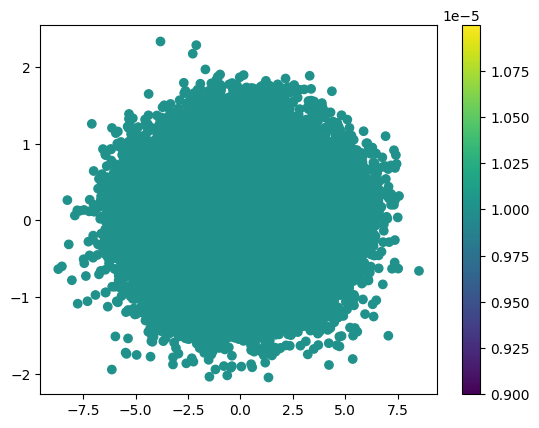

 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning:The following kwargs were not used by contour: 'kind'


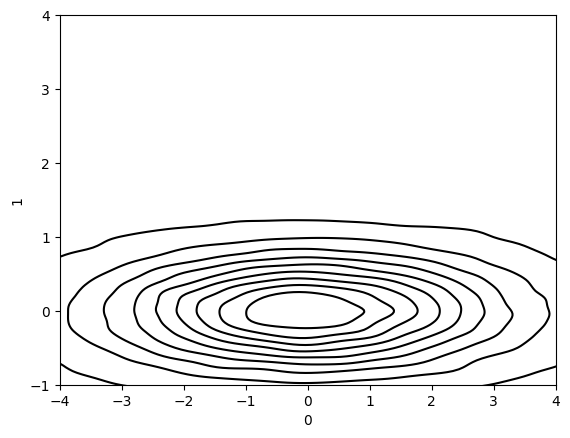

In [5]:

####################################
# 3) laplace integration over model
####################################
# and now the laplace approximation with the banana function
banana_model = Model_from_func(banana_function, input_shape=[2])
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
dict(banana_model.named_parameters())
const_prior = lambda x: torch.tensor(0.0)
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])

xs = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys = banana_function_(xs[0]).unsqueeze(0)



laplace = Laplace(banana_model, xs=xs, ys=ys, loss_fn=neglog_loss(), prior_loss=const_prior)
laplace.fit(fitting_type="hessian", xs=xs, ys=ys)

for i in range(10):
  laplace.make_posterior_sample(n_samples=10000)
  integral_la, function_values_lp, weights_lp, posterior_samples_la = integrator(laplace, functional_evaluation_model, output_func=None, parametersubset=parametersubset, xs=xs)
  laplace.posterior_samples.T.cov()
  print(f"When using the laplace approxiation of posterior of banana MODEL with {laplace.posterior_samples.shape[0]} we get {integral_la = }")

plt.scatter(posterior_samples_la[:,0].detach(), posterior_samples_la[:,1].detach(), c=weights_lp.detach())
plt.colorbar()
plt.show()
plt.close()

df = pd.DataFrame(posterior_samples_la.detach().numpy())
fig, ax =plt.subplots()
sns.kdeplot(df, x=0, y=1, kind="kde", levels=10, color="black", ax=ax)
ax.set_xlim(plot_xlim)
ax.set_ylim(plot_ylim)
plt.savefig(os.path.join(fig_folder, "banana_dist_laplace_isocurves.png"))
plt.show()
plt.close()
#plt.scatter(posterior_samples_la[:,0].detach(), posterior_samples_la[:,1].detach(), c=function_values_lp.detach())


In [6]:
#######################################
# 4) MCMC-integration from banana model
#######################################


# and now the laplace approximation with the banana function
banana_model = Model_from_func(banana_function, input_shape=[2])
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
#loss_fn = lambda preds, target: torch.sum(preds.log())

parametersubset = dict(banana_model.named_parameters())
sampler_mcmc = MCMC_sampler(banana_model, parametersubset, xs=xs, ys=ys, loss_fn=neglog_loss(), prior_loss=const_prior)
_=sampler_mcmc.make_posterior_sample(10000)
sampler_mcmc.posterior_samples.T.cov()

integral_mcmc, function_values_mcmc, weights_mcmc, posterior_samples_mcmc = integrator(sampler_mcmc, functional_evaluation_model, output_func=None, parametersubset=parametersubset, xs=xs)


Sampling (Sampler.HMC; Integrator.IMPLICIT)
Time spent  | Time remain.| Progress             | Samples     | Samples/sec
0d:00:00:16 | 0d:00:00:00 | #################### | 10000/10000 | 624.13       
Acceptance Rate 0.96


When using the MCMC sampling of posterior of banana MODEL with 10000 samples we get integral_mcmc = tensor([[0.8916]])


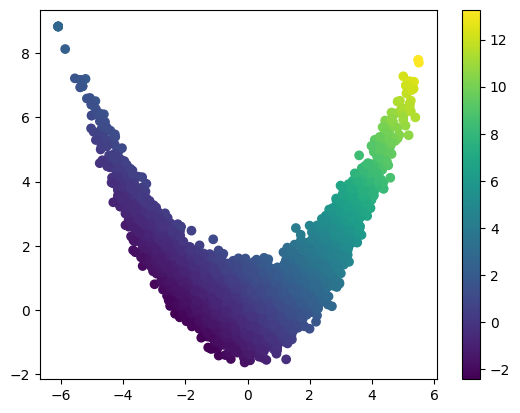

 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/.venv/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning:The following kwargs were not used by contour: 'kind'


In [7]:
print(f"When using the MCMC sampling of posterior of banana MODEL with {sampler_mcmc.posterior_samples.shape[0]} samples we get {integral_mcmc = }")

plt.scatter(posterior_samples_mcmc[:,0].detach(), posterior_samples_mcmc[:,1].detach(), c=function_values_mcmc.detach())
plt.colorbar()
plt.show()
plt.close()

df = pd.DataFrame(posterior_samples_mcmc.detach().numpy(), columns=["x", "y"])
fig, ax =plt.subplots()
sns.kdeplot(df, x="x", y="y", kind="kde", levels=10, color="black", ax=ax)
ax.set_xlim(plot_xlim)
ax.set_ylim(plot_ylim)
plt.savefig(os.path.join(fig_folder, "banana_dist_mcmc_isocurves.png"))
plt.close()

In [8]:
####################################
# 5) Riemannian laplace integration over model
####################################

# and now the laplace approximation with the banana function
banana_model = Model_from_func(banana_function, input_shape=[2])
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
parametersubset = dict(banana_model.named_parameters())

R_sampler = Riemann_sampler(banana_model, parametersubset, xs=xs, ys=ys, loss_fn=neglog_loss(), prior_loss=const_prior, subspace_rank=2)
R_sampler.fit(fitting_type="hessian")

integral_vals_riemann = []
n_samples_riemann = []

BQ = BayesianQuadrature_rays(R_sampler, evaluation_model=evaluation_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-2,2], [-2,2]], xs = xs[0], parametersubset=None)

for i in range(100):
  #_=R_sampler.make_posterior_sample_la(1)
  R_params = R_sampler.make_posterior_sample(10)
  integral_riemann, function_values_riemann, weights_riemann, posterior_samples_riemann = integrator(R_sampler, functional_evaluation_model, output_func=None, parametersubset=parametersubset, xs=xs)
  print(f"When using Riemannian Laplace approximation with {R_sampler.posterior_samples_la.shape[0]} samples we get {integral_riemann = }")
  integral_vals_riemann += [integral_riemann[0,0]]
  n_samples_riemann += [R_sampler.posterior_samples_la.shape[0]]

  # BQ.emukit_model.set_data(X=R_sampler.posterior_samples_la.detach(), Y=function_values_riemann[:,:,0])
  # integral_mean, integral_variance = BQ.emukit_method.integrate()
  # print(f"With added BQ using Riemannian Laplace approximation with {R_sampler.posterior_samples_la.shape[0]} samples we get {integral_mean = }")


 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/riemann_sampler.py:50: UserWarning:The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3687.)


When using Riemannian Laplace approximation with 10 samples we get integral_riemann = tensor([[0.2955]])
When using Riemannian Laplace approximation with 20 samples we get integral_riemann = tensor([[0.4016]])
When using Riemannian Laplace approximation with 30 samples we get integral_riemann = tensor([[0.1192]])
When using Riemannian Laplace approximation with 40 samples we get integral_riemann = tensor([[0.1946]])
When using Riemannian Laplace approximation with 50 samples we get integral_riemann = tensor([[0.0630]])
When using Riemannian Laplace approximation with 60 samples we get integral_riemann = tensor([[0.2464]])
When using Riemannian Laplace approximation with 70 samples we get integral_riemann = tensor([[0.4286]])
When using Riemannian Laplace approximation with 80 samples we get integral_riemann = tensor([[0.3773]])
When using Riemannian Laplace approximation with 90 samples we get integral_riemann = tensor([[0.3832]])
When using Riemannian Laplace approximation with 100 sa

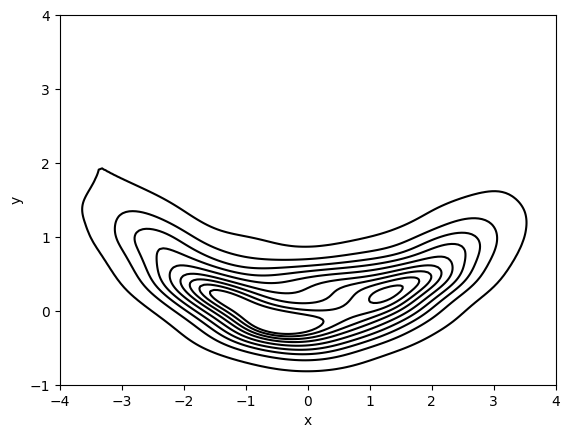

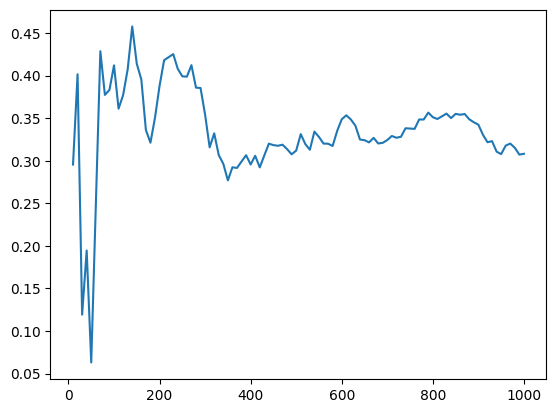

In [9]:
#fig, ax = riemann_plotter(R_sampler, sample_markers=".", plot_traject=True, plot_traj_marker=None, max_samples=None, LA_arrows=[1])

df = pd.DataFrame(R_sampler.posterior_samples.numpy(), columns=["x", "y"])
fig, ax =plt.subplots()
sns.kdeplot(data=df, x="x", y="y", levels=10, color="black", ax=ax)
ax.set_xlim(plot_xlim)
ax.set_ylim(plot_ylim)
plt.savefig(os.path.join(fig_folder, "banana_dist_riemann_isocurves.png"))
plt.show()
plt.close()

plt.plot(n_samples_riemann, integral_vals_riemann)
plt.savefig(os.path.join(fig_folder, "banana_dist_riemann_convergence.png"))
plt.show()
plt.close()


BQ_2d.steps = 1, observations = 7, integral_mean_BQ = tensor([0.2442]), integral_variance_BQ = tensor(0.0499)
BQ_2d.steps = 2, observations = 13, integral_mean_BQ = tensor([0.3874]), integral_variance_BQ = tensor(0.0168)
BQ_2d.steps = 3, observations = 19, integral_mean_BQ = tensor([0.1920]), integral_variance_BQ = tensor(0.0112)
BQ_2d.steps = 4, observations = 25, integral_mean_BQ = tensor([0.1846]), integral_variance_BQ = tensor(0.0060)
BQ_2d.steps = 5, observations = 31, integral_mean_BQ = tensor([0.3225]), integral_variance_BQ = tensor(0.0044)
BQ_2d.steps = 6, observations = 37, integral_mean_BQ = tensor([0.3468]), integral_variance_BQ = tensor(0.0016)
BQ_2d.steps = 7, observations = 43, integral_mean_BQ = tensor([0.4261]), integral_variance_BQ = tensor(0.0009)
BQ_2d.steps = 8, observations = 49, integral_mean_BQ = tensor([0.3016]), integral_variance_BQ = tensor(0.0001)


 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/BQ_rays_subspace.py:398: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


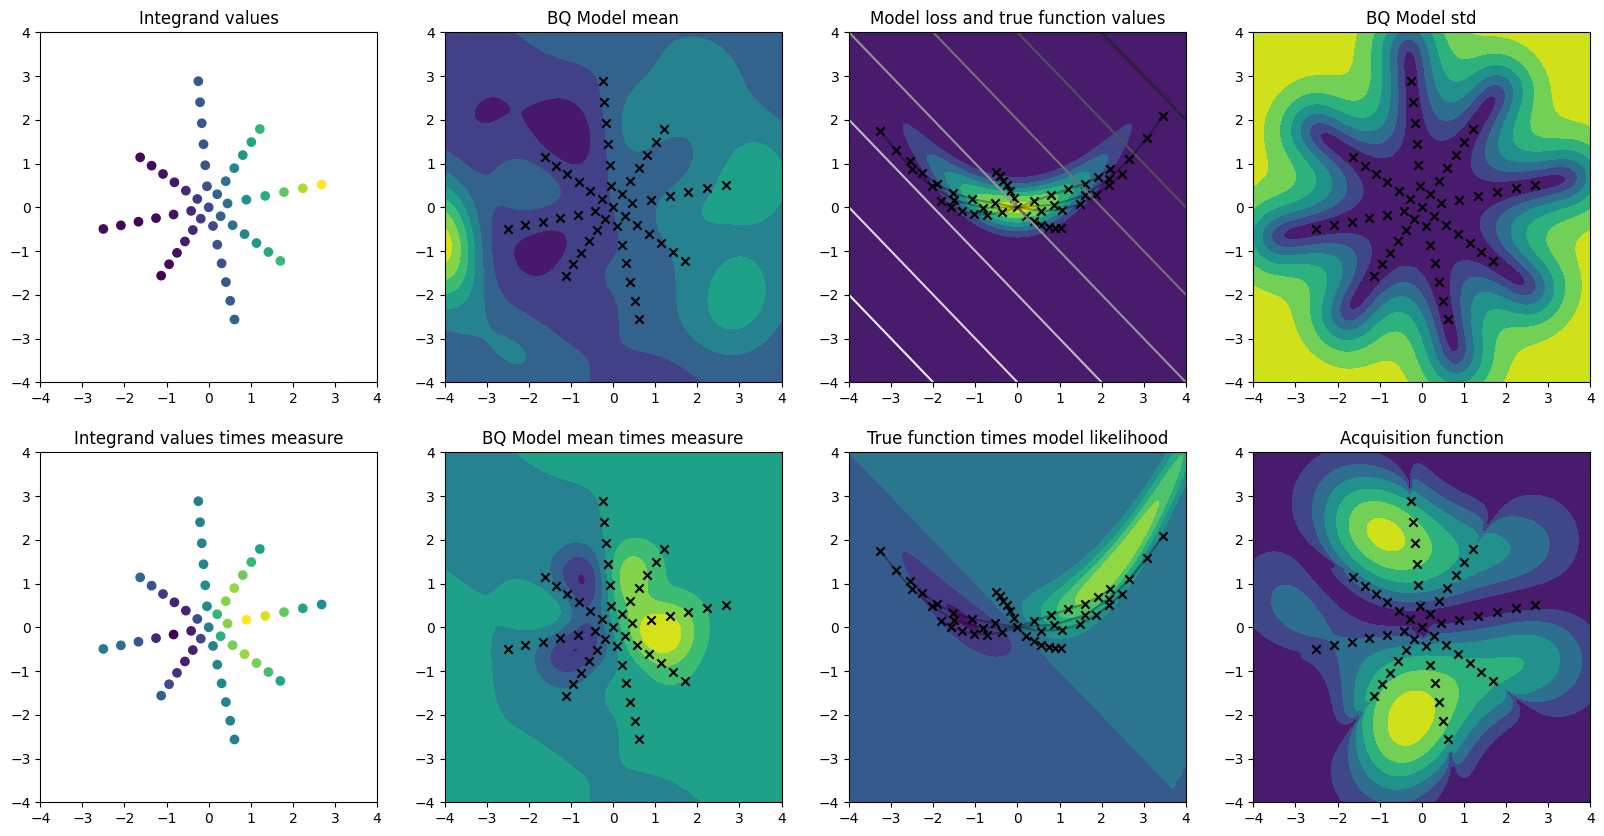

BQ_2d.steps = 9, observations = 55, integral_mean_BQ = tensor([0.3054]), integral_variance_BQ = tensor(7.8171e-05)
BQ_2d.steps = 10, observations = 61, integral_mean_BQ = tensor([0.3606]), integral_variance_BQ = tensor(4.9909e-05)
BQ_2d.steps = 11, observations = 67, integral_mean_BQ = tensor([0.3487]), integral_variance_BQ = tensor(4.1381e-05)
BQ_2d.steps = 12, observations = 73, integral_mean_BQ = tensor([0.3501]), integral_variance_BQ = tensor(3.3848e-05)
BQ_2d.steps = 13, observations = 79, integral_mean_BQ = tensor([0.3391]), integral_variance_BQ = tensor(2.7030e-05)
BQ_2d.steps = 14, observations = 85, integral_mean_BQ = tensor([0.3449]), integral_variance_BQ = tensor(1.8013e-05)
BQ_2d.steps = 15, observations = 91, integral_mean_BQ = tensor([0.3502]), integral_variance_BQ = tensor(9.9719e-06)
BQ_2d.steps = 16, observations = 97, integral_mean_BQ = tensor([0.3251]), integral_variance_BQ = tensor(1.9217e-06)


In [10]:
####################################
# 6) Bayesian Quadrature - Riemannian laplace integration over model
####################################
R_sampler_2d = Riemann_sampler(banana_model, xs=xs, ys=ys, loss_fn=neglog_loss(), prior_loss=const_prior, subspace_rank=2)
_=R_sampler_2d.fit(fitting_type="hessian")

BQ_2d = BayesianQuadrature_rays(R_sampler_2d, evaluation_model=evaluation_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-2,2], [-2,2]], xs = xs[0], parametersubset=None)
BQ_2d.theta_space_plot_limits=[[-4,4], [-4,4]]

integral_vals_riemann_BQ = []
n_samples_riemann_BQ = []
n_steps= []

for i in range(16):
    integral_mean_BQ, integral_variance_BQ = BQ_2d.step()
    print(f"{BQ_2d.steps = }, observations = {BQ_2d.emukit_method.X.shape[0]}, {integral_mean_BQ = }, {integral_variance_BQ = }")
    integral_vals_riemann_BQ += [integral_mean_BQ]
    n_samples_riemann_BQ += [BQ_2d.emukit_method.X.shape[0]]
    n_steps += [BQ_2d.steps]
    if i == 7: 
        fig, axes = BQ_2d.plot()
        plt.savefig(os.path.join(fig_folder, "banana_BQ_integrand_2d.png"))
        plt.show()

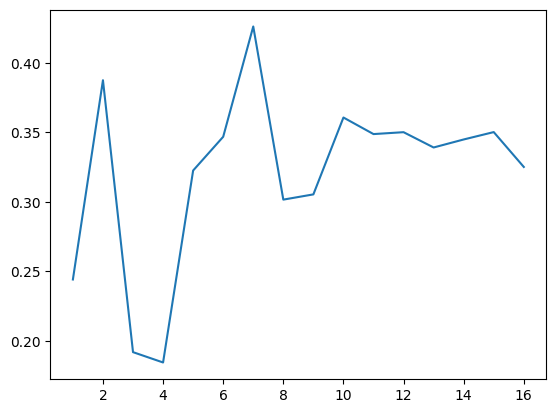

In [11]:
plt.plot(n_steps, integral_vals_riemann_BQ)
plt.savefig(os.path.join(fig_folder, "banana_dist_riemann_BQ_convergence.png"))